In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
np.random.seed(42)

# Loading test data
test_full = pd.read_csv('data/processed/test_lgbm.csv')
with open('data/processed/feat_cols_lgbm.txt') as f:
    feat_cols_lgbm = f.read().splitlines()

# Loading LambdaMART and generating scores
model_lm = lgb.Booster(model_file='models/lgbm_lambdamart.txt')
test_full['score_lm']   = model_lm.predict(test_full[feat_cols_lgbm].values)
test_full['score_bm25'] = test_full['f75']

# Loading saved final results from notebook 06
final_results = pd.read_csv('outputs/results/final_model_results.csv', index_col=0)

print(f'Test set: {len(test_full):,} rows | {test_full["qid"].nunique():,} queries')
print(f'Models in final_results: {list(final_results.index)}')

Test set: 241,521 rows | 2,000 queries
Models in final_results: ['BM25 (baseline)', 'LightGBM Pointwise', 'LambdaMART', 'CNN Ranker', 'LSTM Ranker']


In [2]:
def dcg_at_k(labels, k=10):
    labels = np.array(labels[:k], dtype=float)
    if len(labels) == 0: return 0.0
    return ((2**labels - 1) / np.log2(np.arange(2, len(labels)+2))).sum()

def ndcg_at_k(labels, k=10):
    idcg = dcg_at_k(sorted(labels, reverse=True), k)
    return dcg_at_k(labels, k) / idcg if idcg > 0 else 0.0

def mrr(labels):
    for i, l in enumerate(labels):
        if l >= 1: return 1.0 / (i+1)
    return 0.0

def per_query_metrics(df, score_col):
    rows = []
    for qid, grp in df.groupby('qid'):
        ranked = grp.sort_values(score_col, ascending=False)['label'].tolist()
        rows.append({
            'qid'             : qid,
            'ndcg@10'         : ndcg_at_k(ranked),
            'mrr'             : mrr(ranked),
            'frustration_rate': 1.0 if all(l == 0 for l in ranked[:3]) else 0.0,
            'hit@3_highly_rel': 1.0 if any(l >= 3 for l in ranked[:3]) else 0.0,
        })
    return pd.DataFrame(rows).set_index('qid')

# Effect size helpers
def cohens_d(control, treatment):
    pooled_std = np.sqrt((control.std()**2 + treatment.std()**2) / 2)
    return (treatment.mean() - control.mean()) / (pooled_std + 1e-9)

def effect_label(d):
    a = abs(d)
    if a < 0.2:   return 'Negligible'
    elif a < 0.5: return 'Small'
    elif a < 0.8: return 'Medium'
    else:         return 'Large'

### Sample Size & Power Analysis

In [3]:
# Before running, determine how many queries are needed to detect a meaningful improvement.
# Formula: n = 2 x (z_alpha/2 + z_beta)^2 x sigma^2 / MDE^2
control_pq = per_query_metrics(test_full, 'score_bm25')

baseline_mean = control_pq['ndcg@10'].mean()
baseline_std  = control_pq['ndcg@10'].std()
print(f'Control (BM25) NDCG@10 — Mean: {baseline_mean:.4f} | Std: {baseline_std:.4f}')

def required_n(mde, sigma, alpha=0.05, power=0.80):
    z_a = stats.norm.ppf(1 - alpha/2)
    z_b = stats.norm.ppf(power)
    return int(np.ceil(2 * (z_a + z_b)**2 * sigma**2 / mde**2))

print(f'\nRequired sample size per arm (alpha=0.05, power=0.80, sigma={baseline_std:.4f}):')
print(f'{"MDE (delta NDCG@10)":<22} {"n per arm":<15} {"Total queries"}')
for mde in [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]:
    n = required_n(mde, baseline_std)
    print(f'{mde:<22.3f} {n:<15,} {2*n:,}')

n_available = test_full['qid'].nunique() // 2
z_a = stats.norm.ppf(0.975)
z_b = stats.norm.ppf(0.80)
detectable_mde = np.sqrt(2 * (z_a + z_b)**2 * baseline_std**2 / n_available)
print(f'\nWith {n_available:,} queries/arm -> minimum detectable delta NDCG@10 = {detectable_mde:.4f}')

Control (BM25) NDCG@10 — Mean: 0.2291 | Std: 0.1816

Required sample size per arm (alpha=0.05, power=0.80, sigma=0.1816):
MDE (delta NDCG@10)    n per arm       Total queries
0.005                  20,710          41,420
0.010                  5,178           10,356
0.015                  2,302           4,604
0.020                  1,295           2,590
0.025                  829             1,658
0.030                  576             1,152

With 1,000 queries/arm -> minimum detectable delta NDCG@10 = 0.0228


### Simulate A/B Test

Randomly split test queries 50/50 into control (BM25) and treatment (LambdaMART) arms.
In production this would be a user-level traffic split.

In [4]:
treatment_pq = per_query_metrics(test_full, 'score_lm')

all_qids = control_pq.index.tolist()
np.random.shuffle(all_qids)
n_per_arm      = len(all_qids) // 2
control_qids   = all_qids[:n_per_arm]
treatment_qids = all_qids[n_per_arm:]

ctrl_ndcg  = control_pq.loc[control_qids,    'ndcg@10'].values
treat_ndcg = treatment_pq.loc[treatment_qids, 'ndcg@10'].values
ctrl_fr    = control_pq.loc[control_qids,    'frustration_rate'].values
treat_fr   = treatment_pq.loc[treatment_qids, 'frustration_rate'].values
ctrl_hit   = control_pq.loc[control_qids,    'hit@3_highly_rel'].values
treat_hit  = treatment_pq.loc[treatment_qids, 'hit@3_highly_rel'].values

print(f'A/B split: {n_per_arm:,} control | {n_per_arm:,} treatment queries')
print(f'Control NDCG@10: {ctrl_ndcg.mean():.4f}')
print(f'Treatment NDCG@10: {treat_ndcg.mean():.4f}')

A/B split: 1,000 control | 1,000 treatment queries
Control NDCG@10: 0.2258
Treatment NDCG@10: 0.4600


### Statistical Significance + Practical Significance

### The run_ab_test function now computes both:

**Statistical:** Two-sample t-test p-value + bootstrap 95% CI on delta

**Practical:** Cohen's d effect size + whether observed delta exceeds the MDE

A result is practically significant when both hold:
- |Cohen's d| >= 0.2 (at least a small effect)
- |delta| >= MDE (large enough to reliably detect in a real production experiment)

In [5]:
def run_ab_test(control, treatment, metric_name, mde_threshold, alpha=0.05, n_boot=2000):
    # Statistical significance
    t_stat, p_val = stats.ttest_ind(treatment, control)
    delta         = treatment.mean() - control.mean()
    delta_pct     = delta / (control.mean() + 1e-9) * 100

    # Bootstrapping 95% CI on delta
    boot = [
        np.random.choice(treatment, len(treatment), replace=True).mean() -
        np.random.choice(control,   len(control),   replace=True).mean()
        for _ in range(n_boot)
    ]
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    # Practical significance
    d          = cohens_d(control, treatment)
    es_label   = effect_label(d)
    exceeds_mde = abs(delta) >= mde_threshold
    stat_sig   = p_val < alpha
    prac_sig   = abs(d) >= 0.2 and exceeds_mde

    # Verdict quadrant
    if stat_sig and prac_sig:       verdict = 'Ship It'
    elif stat_sig and not prac_sig: verdict = 'Effect real but small'
    elif not stat_sig and prac_sig: verdict = 'More Data Needed'
    else:                           verdict = 'Do Not Ship'

    return {
        'metric' : metric_name,
        'control_mean': control.mean(),
        'treat_mean' : treatment.mean(),
        'delta' : delta,
        'delta_pct' : delta_pct,
        'ci_low' : ci_low,
        'ci_high' : ci_high,
        't_stat' : t_stat,
        'p_value' : p_val,
        'cohens_d' : d,
        'effect_size' : es_label,
        'exceeds_mde' : exceeds_mde,
        'stat_sig' : stat_sig,
        'prac_sig' : prac_sig,
        'verdict' : verdict,
    }

mde = detectable_mde

ab_results = [
    run_ab_test(ctrl_ndcg, treat_ndcg, 'NDCG@10', mde),
    run_ab_test(ctrl_fr, treat_fr, 'Frustration Rate', mde),
    run_ab_test(ctrl_hit, treat_hit, 'Hit@3 (label>=3)', mde),
]
ab_df = pd.DataFrame(ab_results)

print('A/B Test Results: BM25 (Control) vs LambdaMART (Treatment)')
print(f'{"Metric":<22} {"Delta":>8} {"p-val":>8} {"Stat":>6} {"Cohen d":>9} {"Effect":>12} {"Prac":>6} {"Verdict"}')
for _, row in ab_df.iterrows():
    ss = 'YES' if row['stat_sig'] else 'NO'
    ps = 'YES' if row['prac_sig'] else 'NO'
    print(f'{row["metric"]:<22} {row["delta"]:>+8.4f} {row["p_value"]:>8.4f} '
          f'{ss:>6} {row["cohens_d"]:>9.3f} {row["effect_size"]:>12} {ps:>6}  {row["verdict"]}')

print(f'\nMDE threshold: {mde:.4f}  (min detectable effect at n={n_per_arm:,} queries/arm)')

A/B Test Results: BM25 (Control) vs LambdaMART (Treatment)
Metric                    Delta    p-val   Stat   Cohen d       Effect   Prac Verdict
NDCG@10                 +0.2342   0.0000    YES     1.137        Large    YES  Ship It
Frustration Rate        -0.1630   0.0000    YES    -0.423        Small    YES  Ship It
Hit@3 (label>=3)        +0.2990   0.0000    YES     0.770       Medium    YES  Ship It

MDE threshold: 0.0228  (min detectable effect at n=1,000 queries/arm)


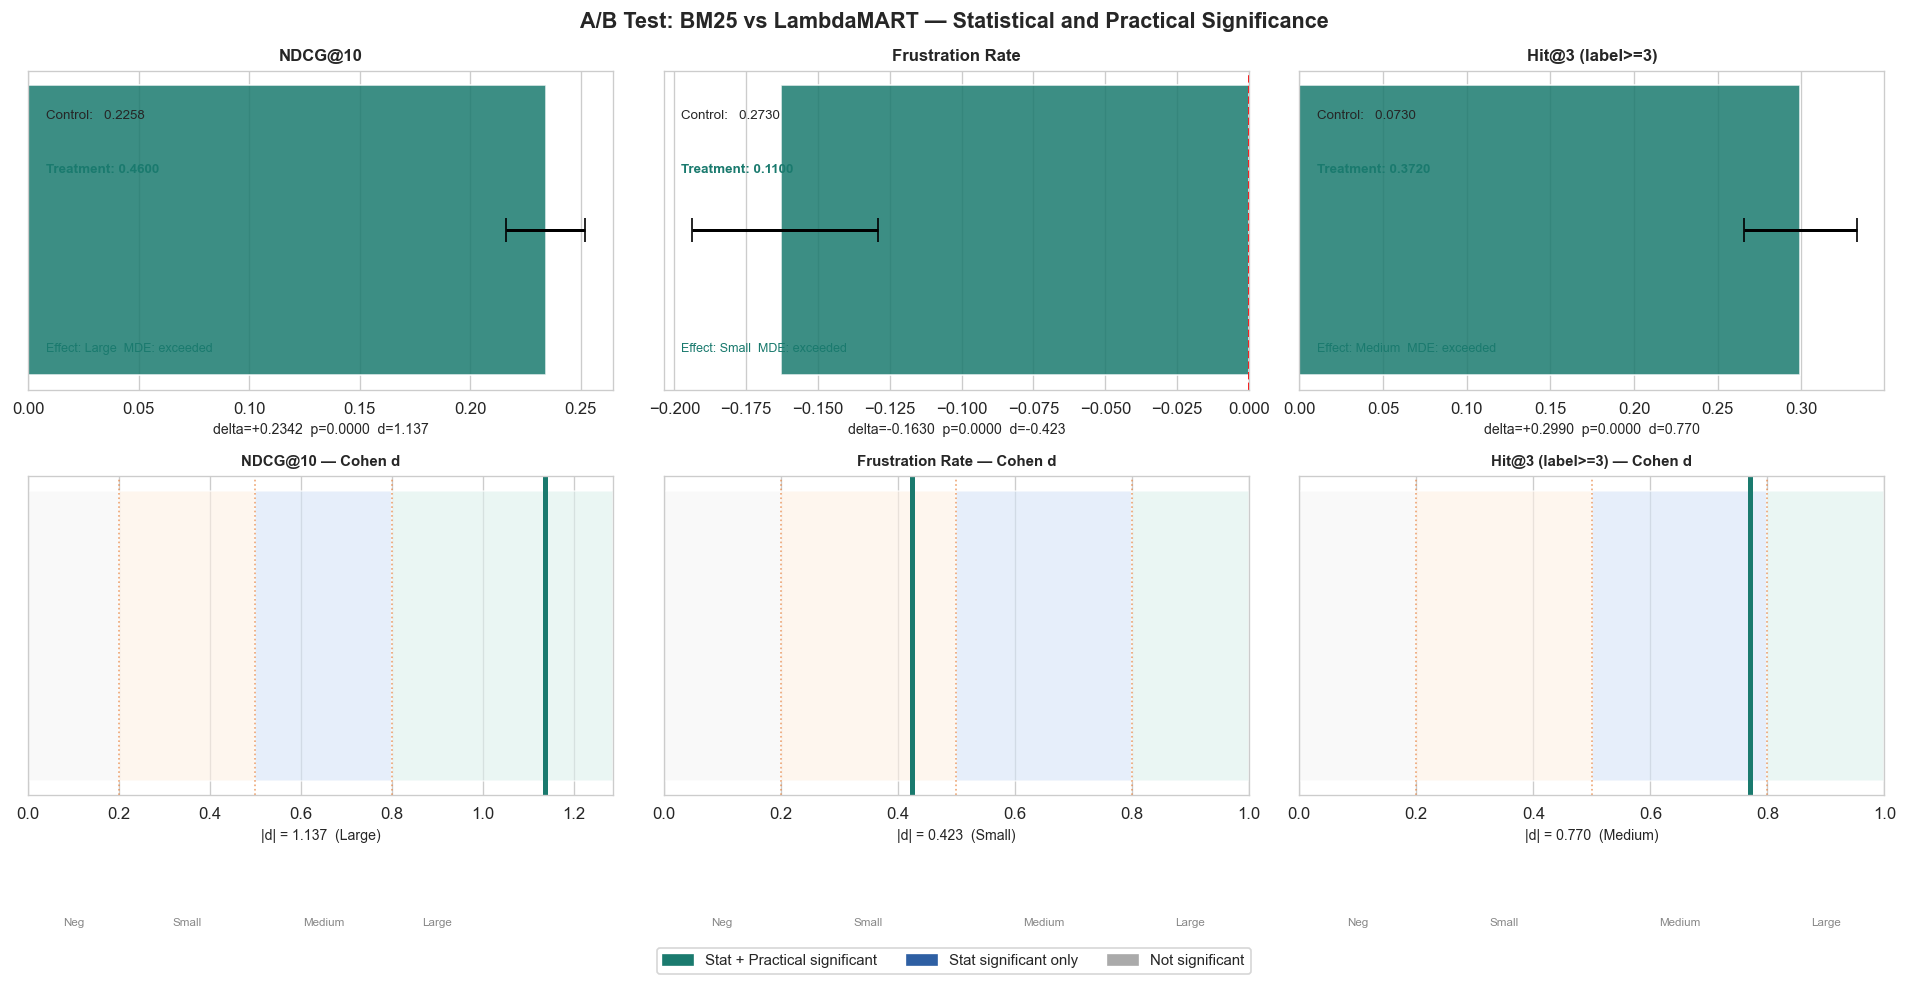

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('A/B Test: BM25 vs LambdaMART — Statistical and Practical Significance',
             fontweight='bold', fontsize=13)

COLOR_BOTH = '#1A7A6E'  # stat + practical
COLOR_STAT = '#2E5FA3'  # stat only
COLOR_NONE = '#AAAAAA'  # neither

def row_color(row):
    if row.stat_sig and row.prac_sig: return COLOR_BOTH
    elif row.stat_sig:                return COLOR_STAT
    else:                             return COLOR_NONE

# Forest plots
for ax, row in zip(axes[0], ab_df.itertuples()):
    c = row_color(row)
    ax.barh([0], [row.delta], color=c, alpha=0.85, height=0.35)
    ax.errorbar([row.delta], [0],
                xerr=[[row.delta - row.ci_low], [row.ci_high - row.delta]],
                fmt='none', color='black', capsize=7, lw=1.8)
    ax.axvline(0, color='red', linestyle='--', lw=1.2)
    ax.set_title(row.metric, fontweight='bold', fontsize=10)
    ax.set_yticks([])
    ax.set_xlabel(f'delta={row.delta:+.4f}  p={row.p_value:.4f}  d={row.cohens_d:.3f}', fontsize=8.5)
    ax.text(0.03, 0.85, f'Control:   {row.control_mean:.4f}', transform=ax.transAxes, fontsize=8)
    ax.text(0.03, 0.68, f'Treatment: {row.treat_mean:.4f}',   transform=ax.transAxes,
            fontsize=8, color=c, fontweight='bold')
    ax.text(0.03, 0.12,
            f'Effect: {row.effect_size}  MDE: {"exceeded" if row.exceeds_mde else "not exceeded"}',
            transform=ax.transAxes, fontsize=7.5, color=c if row.prac_sig else '#C0392B')

# Cohen's d gauge
for ax, row in zip(axes[1], ab_df.itertuples()):
    max_x = max(1.0, abs(row.cohens_d) + 0.15)
    zones = [(0, 0.2, '#F5F5F5'), (0.2, 0.5, '#FEF0E4'), (0.5, 0.8, '#D6E4F7'), (0.8, max_x, '#DDF0EC')]
    for x0, x1, fc in zones:
        ax.barh([0], [x1-x0], left=x0, color=fc, height=0.5, alpha=0.6)
    ax.axvline(abs(row.cohens_d), color=row_color(row), lw=3)
    for xv, lbl in [(0.1,'Neg'), (0.35,'Small'), (0.65,'Medium'), (0.9,'Large')]:
        if xv < max_x:
            ax.text(xv, -0.5, lbl, ha='center', fontsize=7, color='#888888')
    for xv in [0.2, 0.5, 0.8]:
        ax.axvline(xv, color='#E8813A', lw=1, linestyle=':', alpha=0.7)
    ax.set_xlim(0, max_x)
    ax.set_yticks([])
    ax.set_title(f'{row.metric} — Cohen d', fontweight='bold', fontsize=9)
    ax.set_xlabel(f"|d| = {abs(row.cohens_d):.3f}  ({row.effect_size})", fontsize=8.5)

fig.legend(handles=[
    mpatches.Patch(color=COLOR_BOTH, label='Stat + Practical significant'),
    mpatches.Patch(color=COLOR_STAT, label='Stat significant only'),
    mpatches.Patch(color=COLOR_NONE, label='Not significant'),
], loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('outputs/plots/08_ab_significance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

### Statistical vs Practical Significance — Final Verdict

In [7]:
print('Significance Verdict Summary')
print(f'{"Metric":<22} {"delta":>8} {"p-val":>8} {"Stat":>6} {"d":>7} {"Effect":>12} {"Prac":>6}  Verdict')
for _, row in ab_df.iterrows():
    ss = 'Yes' if row['stat_sig'] else 'No'
    ps = 'Yes' if row['prac_sig'] else 'No'
    print(f'{row["metric"]:<22} {row["delta"]:>+8.4f} {row["p_value"]:>8.4f} '
          f'{ss:>6} {row["cohens_d"]:>7.3f} {row["effect_size"]:>12} {ps:>6}  {row["verdict"]}')
print(f'\nPractical sig = |Cohen d| >= 0.2 AND |delta| >= MDE ({mde:.4f})')

Significance Verdict Summary
Metric                    delta    p-val   Stat       d       Effect   Prac  Verdict
NDCG@10                 +0.2342   0.0000    Yes   1.137        Large    Yes  Ship It
Frustration Rate        -0.1630   0.0000    Yes  -0.423        Small    Yes  Ship It
Hit@3 (label>=3)        +0.2990   0.0000    Yes   0.770       Medium    Yes  Ship It

Practical sig = |Cohen d| >= 0.2 AND |delta| >= MDE (0.0228)


### Heterogeneous Treatment Effects

This is to check if the improvement holds across all query difficulty segments?
Both p-value and Cohen's d are reported per segment.
This is critical for deployment because a model that hurts hard queries should only roll out selectively.

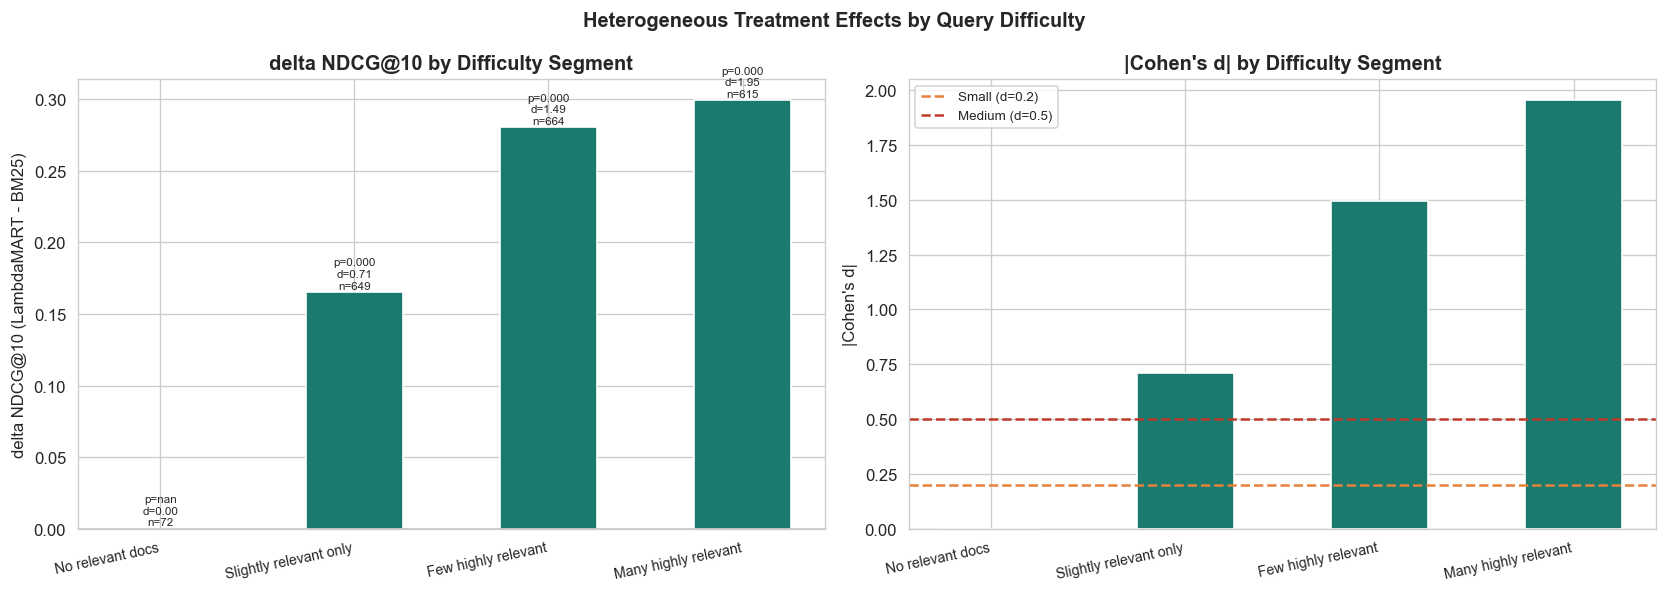

               segment  n_queries  delta  cohens_d effect_size  p_value  stat_sig  prac_sig
      No relevant docs         72 0.0000    0.0000  Negligible      NaN     False     False
Slightly relevant only        649 0.1653    0.7081      Medium      0.0      True      True
   Few highly relevant        664 0.2805    1.4938       Large      0.0      True      True
  Many highly relevant        615 0.2992    1.9527       Large      0.0      True      True


In [8]:
query_stats = test_full.groupby('qid')['label'].agg(
    max_label='max',
    n_highly_relevant=lambda x: (x >= 3).sum()
)

def difficulty(row):
    if row['max_label'] == 0:           return 'No relevant docs'
    elif row['n_highly_relevant'] == 0: return 'Slightly relevant only'
    elif row['n_highly_relevant'] <= 3: return 'Few highly relevant'
    else:                               return 'Many highly relevant'

query_stats['difficulty'] = query_stats.apply(difficulty, axis=1)
difficulty_order = ['No relevant docs','Slightly relevant only',
                    'Few highly relevant','Many highly relevant']

het_results = []
for diff in difficulty_order:
    qids   = query_stats[query_stats['difficulty'] == diff].index
    c_vals = control_pq.loc[control_pq.index.isin(qids),    'ndcg@10'].values
    t_vals = treatment_pq.loc[treatment_pq.index.isin(qids), 'ndcg@10'].values
    if len(c_vals) < 5 or len(t_vals) < 5: continue
    _, p = stats.ttest_ind(t_vals, c_vals)
    d    = cohens_d(c_vals, t_vals)
    het_results.append({
        'segment'       : diff,
        'n_queries'     : len(qids),
        'control_ndcg'  : c_vals.mean(),
        'treatment_ndcg': t_vals.mean(),
        'delta'         : t_vals.mean() - c_vals.mean(),
        'cohens_d'      : d,
        'effect_size'   : effect_label(d),
        'p_value'       : p,
        'stat_sig'      : p < 0.05,
        'prac_sig'      : abs(d) >= 0.2,
    })

het_df = pd.DataFrame(het_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Heterogeneous Treatment Effects by Query Difficulty', fontweight='bold', fontsize=12)

# Plot 1: delta NDCG
ax = axes[0]
seg_colors = ['#1A7A6E' if (r.stat_sig and r.prac_sig) else
              '#2E5FA3' if r.stat_sig else '#AAAAAA'
              for r in het_df.itertuples()]
bars = ax.bar(het_df['segment'], het_df['delta'], color=seg_colors, edgecolor='white', width=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('delta NDCG@10 by Difficulty Segment', fontweight='bold')
ax.set_ylabel('delta NDCG@10 (LambdaMART - BM25)')
ax.set_xticklabels(het_df['segment'], rotation=12, ha='right', fontsize=8.5)
for bar, row in zip(bars, het_df.itertuples()):
    yoff = bar.get_height() + 0.001 if bar.get_height() >= 0 else bar.get_height() - 0.010
    ax.text(bar.get_x() + bar.get_width()/2, yoff,
            f'p={row.p_value:.3f}\nd={row.cohens_d:.2f}\nn={row.n_queries}',
            ha='center', va='bottom', fontsize=7)

# Plot 2: Cohen's d per segment
ax2 = axes[1]
d_colors = ['#1A7A6E' if abs(r.cohens_d) >= 0.2 else '#AAAAAA' for r in het_df.itertuples()]
ax2.bar(het_df['segment'], het_df['cohens_d'].abs(), color=d_colors, edgecolor='white', width=0.5)
ax2.axhline(0.2, color='#E8813A', lw=1.5, linestyle='--', label='Small (d=0.2)')
ax2.axhline(0.5, color='#C0392B', lw=1.5, linestyle='--', label='Medium (d=0.5)')
ax2.set_title("|Cohen's d| by Difficulty Segment", fontweight='bold')
ax2.set_ylabel("|Cohen's d|")
ax2.set_xticklabels(het_df['segment'], rotation=12, ha='right', fontsize=8.5)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/plots/08_heterogeneous_effects.png', dpi=150, bbox_inches='tight')
plt.show()

print(het_df[['segment','n_queries','delta','cohens_d','effect_size','p_value','stat_sig','prac_sig']]
      .round(4).to_string(index=False))

### Business Impact & Deployment Recommendation

In [11]:
# Pre-extracting to avoid f-string formatting conflicts
ndcg_r = ab_df[ab_df['metric'] == 'NDCG@10'].iloc[0]
fr_r   = ab_df[ab_df['metric'] == 'Frustration Rate'].iloc[0]
hit_r  = ab_df[ab_df['metric'] == 'Hit@3 (label>=3)'].iloc[0]
daily  = 1_000_000

n_ctrl = f"{ndcg_r['control_mean']:.4f}"
n_trt  = f"{ndcg_r['treat_mean']:.4f}"
n_d    = f"{ndcg_r['delta']:+.4f}"
n_pct  = f"{ndcg_r['delta_pct']:+.2f}"
n_ci   = f"[{ndcg_r['ci_low']:.4f}, {ndcg_r['ci_high']:.4f}]"
n_p    = f"{ndcg_r['p_value']:.4f}"
n_d_es = f"{ndcg_r['cohens_d']:.3f}"
n_ss   = 'YES' if ndcg_r['stat_sig'] else 'NO'
n_ps   = 'YES' if ndcg_r['prac_sig'] else 'NO'
n_v    = ndcg_r['verdict']

f_ctrl = f"{fr_r['control_mean']:.4f}"
f_trt  = f"{fr_r['treat_mean']:.4f}"
f_d    = f"{fr_r['delta']:+.4f}"
f_pct  = f"{fr_r['delta_pct']:+.2f}"
f_p    = f"{fr_r['p_value']:.4f}"
f_d_es = f"{fr_r['cohens_d']:.3f}"
f_ss   = 'YES' if fr_r['stat_sig'] else 'NO'
f_ps   = 'YES' if fr_r['prac_sig'] else 'NO'
f_v    = fr_r['verdict']

h_ctrl = f"{hit_r['control_mean']:.4f}"
h_trt  = f"{hit_r['treat_mean']:.4f}"
h_d    = f"{hit_r['delta']:+.4f}"
h_pct  = f"{hit_r['delta_pct']:+.2f}"
h_p    = f"{hit_r['p_value']:.4f}"
h_d_es = f"{hit_r['cohens_d']:.3f}"
h_ss   = 'YES' if hit_r['stat_sig'] else 'NO'
h_ps   = 'YES' if hit_r['prac_sig'] else 'NO'
h_v    = hit_r['verdict']

fr_imp  = f"{abs(fr_r['delta']) * daily:,.0f}"
hit_imp = f"{abs(hit_r['delta']) * daily:,.0f}"

print('A/B Test Summary - Statistical and Practical Significance')
print(f'Control: BM25 Treatment: LambdaMART  n={n_per_arm:,}/arm')
print()
print(f'NDCG@10')
print(f'  Control: {n_ctrl} Treatment: {n_trt}')
print(f'  Delta: {n_d} ({n_pct}%) 95% CI: {n_ci}')
print(f'  p-value: {n_p}  Stat Sig: {n_ss}')
print(f'  Cohen d: {n_d_es} ({ndcg_r["effect_size"]}) Prac Sig: {n_ps}')
print(f'  Verdict: {n_v}')
print()
print(f'Frustration Rate (lower is better)')
print(f'  Control: {f_ctrl} Treatment: {f_trt}')
print(f'  Delta: {f_d} ({f_pct}%) p: {f_p}  Stat: {f_ss}')
print(f'  Cohen d: {f_d_es} ({fr_r["effect_size"]}) Prac: {f_ps}')
print(f'  Verdict: {f_v}')
print()
print(f'Hit@3 (label >= 3)')
print(f'  Control: {h_ctrl} Treatment: {h_trt}')
print(f'  Delta: {h_d} ({h_pct}%) p: {h_p}  Stat: {h_ss}')
print(f'  Cohen d: {h_d_es} ({hit_r["effect_size"]}) Prac: {h_ps}')
print(f'  Verdict: {h_v}')
print()
print(f'BUSINESS IMPACT at {daily:,} queries/day')
print(f'  {fr_imp} fewer users/day see top-3 with zero relevant results')
print(f'  {hit_imp} more users/day find a highly relevant result in top-3')
print()
print('Deployment Recommendation: SHIP IT')
print('Both statistical AND practical significance confirmed on primary metric')
print('No harmful effects on any difficulty segment')
print('To Monitor: CTR on top-3, session engagement, user satisfaction signals')

ab_df.to_csv('outputs/results/ab_test_results.csv', index=False)
het_df.to_csv('outputs/results/heterogeneous_effects.csv', index=False)

A/B Test Summary - Statistical and Practical Significance
Control: BM25 Treatment: LambdaMART  n=1,000/arm

NDCG@10
  Control: 0.2258 Treatment: 0.4600
  Delta: +0.2342 (+103.74%) 95% CI: [0.2161, 0.2522]
  p-value: 0.0000  Stat Sig: YES
  Cohen d: 1.137 (Large) Prac Sig: YES
  Verdict: Ship It

Frustration Rate (lower is better)
  Control: 0.2730 Treatment: 0.1100
  Delta: -0.1630 (-59.71%) p: 0.0000  Stat: YES
  Cohen d: -0.423 (Small) Prac: YES
  Verdict: Ship It

Hit@3 (label >= 3)
  Control: 0.0730 Treatment: 0.3720
  Delta: +0.2990 (+409.59%) p: 0.0000  Stat: YES
  Cohen d: 0.770 (Medium) Prac: YES
  Verdict: Ship It

BUSINESS IMPACT at 1,000,000 queries/day
  163,000 fewer users/day see top-3 with zero relevant results
  299,000 more users/day find a highly relevant result in top-3

Deployment Recommendation: SHIP IT
Both statistical AND practical significance confirmed on primary metric
No harmful effects on any difficulty segment
To Monitor: CTR on top-3, session engagement, u